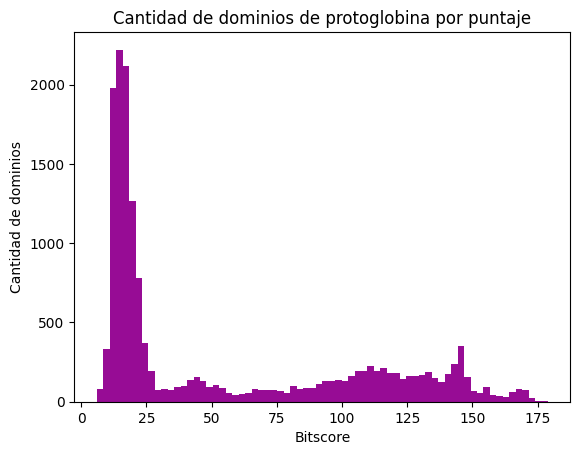

In [130]:
#Ejercicio 2.a

from Bio import SearchIO
import matplotlib.pyplot as plt

def puntajes(resultados: list) -> list:
    lista_puntajes = []
    for hit in resultados:
        for dominio in hit:
            lista_puntajes.append(dominio.bitscore)
    return lista_puntajes

result_proto = SearchIO.read("busqueda.out", "hmmer3-text")
puntajes_proto = puntajes(result_proto)

def graf_histograma_puntajes(elementos: str, titulo: str, nombre: str):
    plt.hist(elementos, bins=70, color="#970c95")
    plt.title(titulo)
    plt.xlabel("Bitscore")
    plt.ylabel("Cantidad de dominios")
    plt.savefig(nombre)

graf_histograma_puntajes(puntajes_proto, "Cantidad de dominios de protoglobina por puntaje", "histograma protoglobina")


In [120]:
#Ejercicio 2.b IDs preguntar si los querían así

from Bio import SeqIO
import pandas as pd

def extraerPosiciones(resultados: list, puntaje_corte: float):
    lista = []
    for secuencia in resultados:
        for dominio in secuencia:
            if dominio.bitscore > puntaje_corte:
                raw_id = dominio.hit_id
                lista.append((uniprotID(raw_id), dominio.hit_start, dominio.hit_end))
    return lista

def uniprotID(id: str):
    if "|" in id:
        return id.split("|")[1]
    else:
        return id

#Viendo el histograma, inferimos que los puntajes menores a 50 son "ruido"

lista_ids = extraerPosiciones(result_proto, 50)
print("Cantidad de dominios de protoglobina encontrados:",len(lista_ids))
df = pd.DataFrame(lista_ids, columns=["ID", "Inicio", "Fin"])
df.head()

Cantidad de dominios de protoglobina encontrados: 5955


,ID,Inicio,Fin
0,G0RZQ1,19,200
1,A0A175VX62,20,200
2,B2AU65,20,200
3,A0A3E0RFZ9,36,190
4,F7VKQ0,26,207


In [121]:
#Ejercicio 2.b archivo fasta (VER SI HAY QUE AÑADIR LA DESCRIPCION AL CODIGO)
#revisar si tengo que devolver la secuencia cortada o si devuelvo la secuencia completa

def guardarDominios(lista: list, nombre: str):
    fasta_inicial = SeqIO.to_dict(SeqIO.parse("globin_full_seq.fasta", "fasta"))
    fasta = {}
    for key, value in fasta_inicial.items():
        nuevo = uniprotID(key)
        valor = fasta_inicial[key]
        fasta[nuevo] = valor

    registros_nuevos = []
    for uid, start, end in lista:
        if uid in fasta:
            seq = fasta[uid]
            seq.seq = seq.seq[start-1:end]
            seq.id = uid+ "/" + str(start) + "-" + str(end)
            seq.description = ""
            registros_nuevos.append(seq)

    SeqIO.write(registros_nuevos, nombre, "fasta")

guardarDominios(lista_ids, "proto_salida.fasta")

Ejercicio 2.c

En el ejercicio anterior, vimos la longitud de la lista de ids y vimos que encontramos 5955 dominios, aunque no podemos afirmar que no hallamos excluído algunos ya que los filtramos con un umbral definido por nosotros, lo que pudo haber excluido falsos negativos (protoglobinas muy divergentes). Tampoco podemos afirmar que todos los dominios hallados sean protoglobina, ya que el HMM detecta similitud estadística con el modelo, por lo que falsos positivos (globinas similares).

In [ ]:
#Ejercicio 3.a en jalview se observa la histidina consrvada
#mafft 368, hmm 261, python lee desde la columna 0
from Bio import AlignIO

def histidinaF8(archivo: str, formato: str, columna: int) -> float:
    align = AlignIO.read(archivo, formato)
    align_pd = pd.DataFrame(align)
    col = align_pd[columna - 1]
    aminos = col[col != "-"]
    cantidad_histidina = (aminos == "H").sum()
    return round((cantidad_histidina / len(aminos) * 100), 2)

def calcula_gaps(archivo: str, formato: str, columna: int) -> float:
    align = AlignIO.read(archivo, formato)
    df = pd.DataFrame(align)
    col = df[columna - 1]
    gaps = (col == "-").sum()
    return round(gaps / len(col) * 100, 2)

print("Porcentaje de histidina en F8 según MAFFT:",
    histidinaF8("/home/pizza/Escritorio/Bioinformática/TP 4/dominios_mafft.fasta", "fasta", 368))
print("Porcentaje de histidina en F8 según HMMalign:",
    histidinaF8("/home/pizza/Escritorio/Bioinformática/TP 4/alin_seqs.sto", "stockholm", 261))
print("Porcentaje de gaps en F8 según MAFFT:",
    calcula_gaps("/home/pizza/Escritorio/Bioinformática/TP 4/dominios_mafft.fasta", "fasta", 368))
print("Porcentaje de gaps en F8 según HMMalign:",
    calcula_gaps("/home/pizza/Escritorio/Bioinformática/TP 4/alin_seqs.sto", "stockholm", 261))

Porcentaje de histidina en F8 según MAFFT: 94.04
Porcentaje de histidina en F8 según HMMalign: 93.76
Porcentaje de gaps en F8 según MAFFT: 2.2
Porcentaje de gaps en F8 según HMMalign: 2.0


Se puede observar que el porcentaje de histidina es muy similar en ambos alineamientos, al igual que la proporción de gaps. Sin embargo, la histidina F8 se localiza en columnas diferentes, ya que en el MSA hecho por MAFFT se encuentra en la columna 368 y en el MSA hecho por HMMER la histidina está en la columna 261. Esto se debe a que el MSA hecho por MAFFT inserta mas gaps ya que ignora las funciones biológicas al alinear.

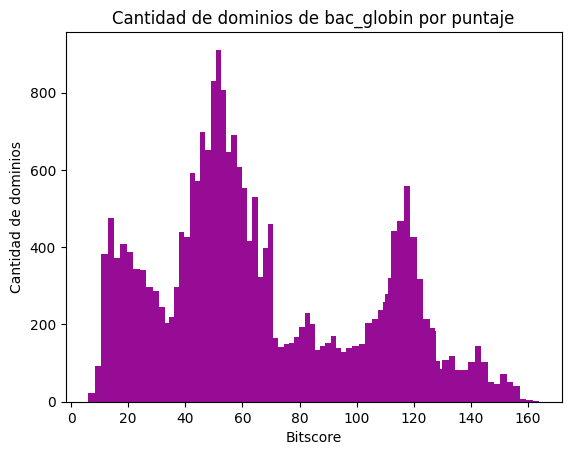

In [ ]:
#Ejercicio 3.b.2 fijarse el tema del umbral

result_globin = SearchIO.read("globin.out", "hmmer3-text")
puntajes_globin = puntajes(result_globin)
graf_histograma_puntajes(puntajes_globin, "Cantidad de dominios de globina por puntaje", "histograma globina")

result_bac_globin = SearchIO.read("bac_globin.out", "hmmer3-text")
puntajes_bac_globin = puntajes(result_bac_globin)
graf_histograma_puntajes(puntajes_bac_globin, "Cantidad de dominios de bac_globin por puntaje", "histograma bac_globin")

ids_globin = extraerPosiciones(result_globin, 73)
guardarDominios(ids_globin, "globin_salida.fasta")
ids_bac_globin = extraerPosiciones(result_bac_globin, 73)
guardarDominios(ids_bac_globin, "bac_globin_salida.fasta")

In [ ]:
#Ejercicio 3.b.3 no hay solapamiento

set_proto = set(x[0] for x in lista_ids)
set_globin = set(x[0] for x in ids_globin)
set_bac_globin = set(x[0] for x in ids_bac_globin)

compartidos = set_bac_globin & set_globin & set_proto
print("Aparecen en los 3 sets:", compartidos)

Aparecen en los 3 sets: set()
